### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

### Load dataset

In [2]:
data = pd.read_csv('C:/Users/91808/RP2 Internship/Capstone project/b_depressed.csv')

In [3]:
data.head()

,Survey_id,Ville_id,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,...,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
0,926,91,1,28,1,4,10,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1,747,57,1,23,1,3,8,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,1
2,1190,115,1,22,1,3,9,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
3,1065,97,1,27,1,2,10,4,52667108,19698904,...,0,1,0,1,22288055,18751329,0,7781123,69219765.0,0
4,806,42,0,59,0,4,10,6,82606287,17352654,...,1,0,0,0,53384566,20731006,1,20100562,43419447.0,0


In [4]:
data.tail()

,Survey_id,Ville_id,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,...,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
1424,255,22,1,25,1,1,7,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1425,547,69,1,28,1,4,10,6,15711078,24023054,...,0,1,0,0,23022095,1021536,0,1823477,47384361.0,0
1426,893,184,1,66,0,0,1,1,42440731,22861940,...,0,1,0,0,12545373,10454478,0,46444572,10454478.0,1
1427,363,75,1,51,1,1,12,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1428,231,12,1,33,0,4,8,5,81678391,22861940,...,0,1,0,1,20019212,16682677,0,69642126,13012488.0,0


### EDA

In [5]:
data.columns

Index(['Survey_id', 'Ville_id', 'sex', 'Age', 'Married', 'Number_children',
       'education_level', 'total_members', 'gained_asset', 'durable_asset',
       'save_asset', 'living_expenses', 'other_expenses', 'incoming_salary',
       'incoming_own_farm', 'incoming_business', 'incoming_no_business',
       'incoming_agricultural', 'farm_expenses', 'labor_primary',
       'lasting_investment', 'no_lasting_investmen', 'depressed'],
      dtype='object')

In [6]:
data.shape

(1429, 23)

In [7]:
data.describe()

,Survey_id,Ville_id,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,...,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
count,1429.00000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1.429000e+03,1.429000e+03,...,1429.000000,1429.000000,1429.000000,1429.000000,1.429000e+03,1.429000e+03,1429.000000,1.429000e+03,1.409000e+03,1429.000000
mean,715.00000,76.286214,0.918125,34.777467,0.772568,2.883135,8.687194,4.969209,3.363448e+07,2.717296e+07,...,0.179846,0.251924,0.107768,0.260322,3.451039e+07,3.549153e+07,0.213436,3.299222e+07,3.360385e+07,0.166550
std,412.66108,66.444012,0.274271,13.986219,0.419320,1.874472,2.923532,1.786317,2.003854e+07,1.815672e+07,...,0.384194,0.434270,0.310195,0.438964,2.077846e+07,2.112372e+07,0.409876,2.121621e+07,2.160228e+07,0.372704
min,1.00000,1.000000,0.000000,17.000000,0.000000,0.000000,1.000000,1.000000,3.251120e+05,1.625560e+05,...,0.000000,0.000000,0.000000,0.000000,3.251120e+05,2.715050e+05,0.000000,7.429200e+04,1.263120e+05,0.000000
25%,358.00000,24.000000,1.000000,25.000000,1.000000,2.000000,8.000000,4.000000,2.326982e+07,1.929852e+07,...,0.000000,0.000000,0.000000,0.000000,2.322229e+07,2.279966e+07,0.000000,2.001911e+07,2.064203e+07,0.000000
50%,715.00000,57.000000,1.000000,30.000000,1.000000,3.000000,9.000000,5.000000,2.891220e+07,2.286194e+07,...,0.000000,0.000000,0.000000,0.000000,3.002882e+07,3.136343e+07,0.000000,2.841172e+07,2.829271e+07,0.000000
75%,1072.00000,105.000000,1.000000,42.000000,1.000000,4.000000,10.000000,6.000000,3.717283e+07,2.656950e+07,...,0.000000,1.000000,0.000000,1.000000,4.003842e+07,4.348584e+07,0.000000,3.982686e+07,4.151762e+07,0.000000
max,1429.00000,292.000000,1.000000,91.000000,1.000000,11.000000,19.000000,12.000000,9.912755e+07,9.961560e+07,...,1.000000,1.000000,1.000000,1.000000,9.978910e+07,9.965119e+07,1.000000,9.944667e+07,9.965119e+07,1.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Survey_id              1429 non-null   int64  
 1   Ville_id               1429 non-null   int64  
 2   sex                    1429 non-null   int64  
 3   Age                    1429 non-null   int64  
 4   Married                1429 non-null   int64  
 5   Number_children        1429 non-null   int64  
 6   education_level        1429 non-null   int64  
 7   total_members          1429 non-null   int64  
 8   gained_asset           1429 non-null   int64  
 9   durable_asset          1429 non-null   int64  
 10  save_asset             1429 non-null   int64  
 11  living_expenses        1429 non-null   int64  
 12  other_expenses         1429 non-null   int64  
 13  incoming_salary        1429 non-null   int64  
 14  incoming_own_farm      1429 non-null   int64  
 15  inco

In [9]:
data[['sex', 'Age', 'Married']].head()

,sex,Age,Married
0,1,28,1
1,1,23,1
2,1,22,1
3,1,27,1
4,0,59,0


In [10]:
data.isnull().sum()

Survey_id                 0
Ville_id                  0
sex                       0
Age                       0
Married                   0
Number_children           0
education_level           0
total_members             0
gained_asset              0
durable_asset             0
save_asset                0
living_expenses           0
other_expenses            0
incoming_salary           0
incoming_own_farm         0
incoming_business         0
incoming_no_business      0
incoming_agricultural     0
farm_expenses             0
labor_primary             0
lasting_investment        0
no_lasting_investmen     20
depressed                 0
dtype: int64

In [11]:
no_lasting_investmen = data['no_lasting_investmen'].mean()

In [12]:
data['no_lasting_investmen'] = data['no_lasting_investmen'].fillna(no_lasting_investmen)

In [13]:
data.isnull().sum()

Survey_id                0
Ville_id                 0
sex                      0
Age                      0
Married                  0
Number_children          0
education_level          0
total_members            0
gained_asset             0
durable_asset            0
save_asset               0
living_expenses          0
other_expenses           0
incoming_salary          0
incoming_own_farm        0
incoming_business        0
incoming_no_business     0
incoming_agricultural    0
farm_expenses            0
labor_primary            0
lasting_investment       0
no_lasting_investmen     0
depressed                0
dtype: int64

### Univariate analysis

<AxesSubplot:xlabel='gained_asset', ylabel='Count'>

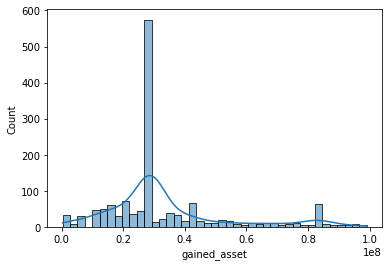

In [14]:
sns.histplot(x = data['gained_asset'],kde = True)

<AxesSubplot:xlabel='farm_expenses', ylabel='Count'>

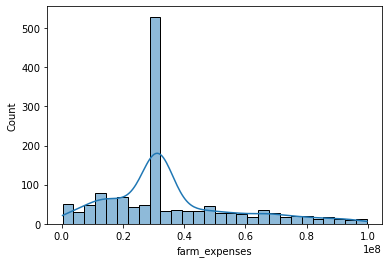

In [15]:
sns.histplot(x = data['farm_expenses'],kde = True)

<AxesSubplot:xlabel='save_asset', ylabel='Count'>

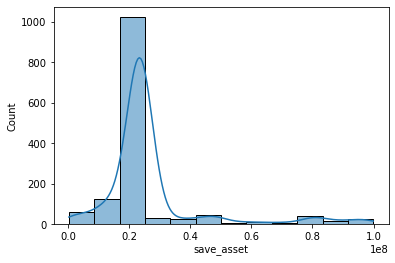

In [16]:
sns.histplot(x = data['save_asset'],kde = True)

In [17]:
d = data['depressed'].value_counts()
d

0    1191
1     238
Name: depressed, dtype: int64

In [18]:
x = d[0]
y = d[1]

([<matplotlib.patches.Wedge at 0x25845570e80>,
 [Text(-0.9528293962064043, 0.5496509271573543, 'Not depressed'),
  Text(0.9528293962064043, -0.5496509271573544, 'Depressed')],
 [Text(-0.5197251252034931, 0.29980959663128415, '83.34%'),
  Text(0.5197251252034931, -0.2998095966312842, '16.66%')])

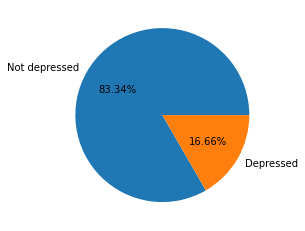

In [19]:
plt.pie([x,y],labels = ['Not depressed','Depressed'],autopct = '%.2f%%')

###  Bivariate analysis

In [20]:
a = data.groupby('sex')['gained_asset'].sum()

Text(0.5, 1.0, 'Sex vs Gained Asset')

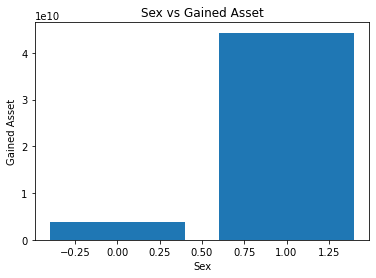

In [21]:
plt.bar(a.index,a.values)
plt.xlabel('Sex')
plt.ylabel('Gained Asset')
plt.title('Sex vs Gained Asset')

<AxesSubplot:xlabel='education_level', ylabel='gained_asset'>

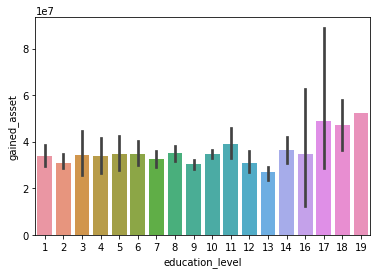

In [22]:
sns.barplot(x = data['education_level'],y = data['gained_asset'])

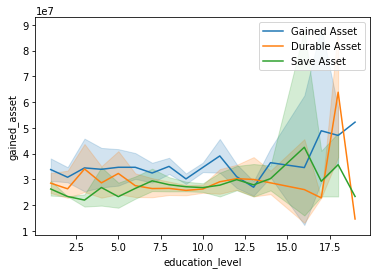

In [23]:
sns.lineplot(x = data['education_level'],y = data['gained_asset'],label = 'Gained Asset')
sns.lineplot(x = data['education_level'],y = data['durable_asset'],label = 'Durable Asset')
sns.lineplot(x = data['education_level'],y = data['save_asset'],label = 'Save Asset')
plt.legend()

<AxesSubplot:xlabel='sex', ylabel='depressed'>

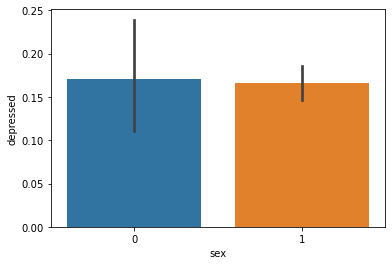

In [24]:
sns.barplot(x = data['sex'],y = data['depressed'])

<AxesSubplot:xlabel='depressed'>

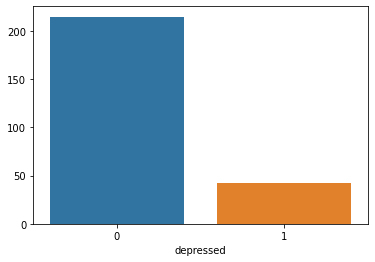

In [25]:
b = data.groupby('depressed')['incoming_salary'].sum()
sns.barplot(x = b.index,y = b.values)

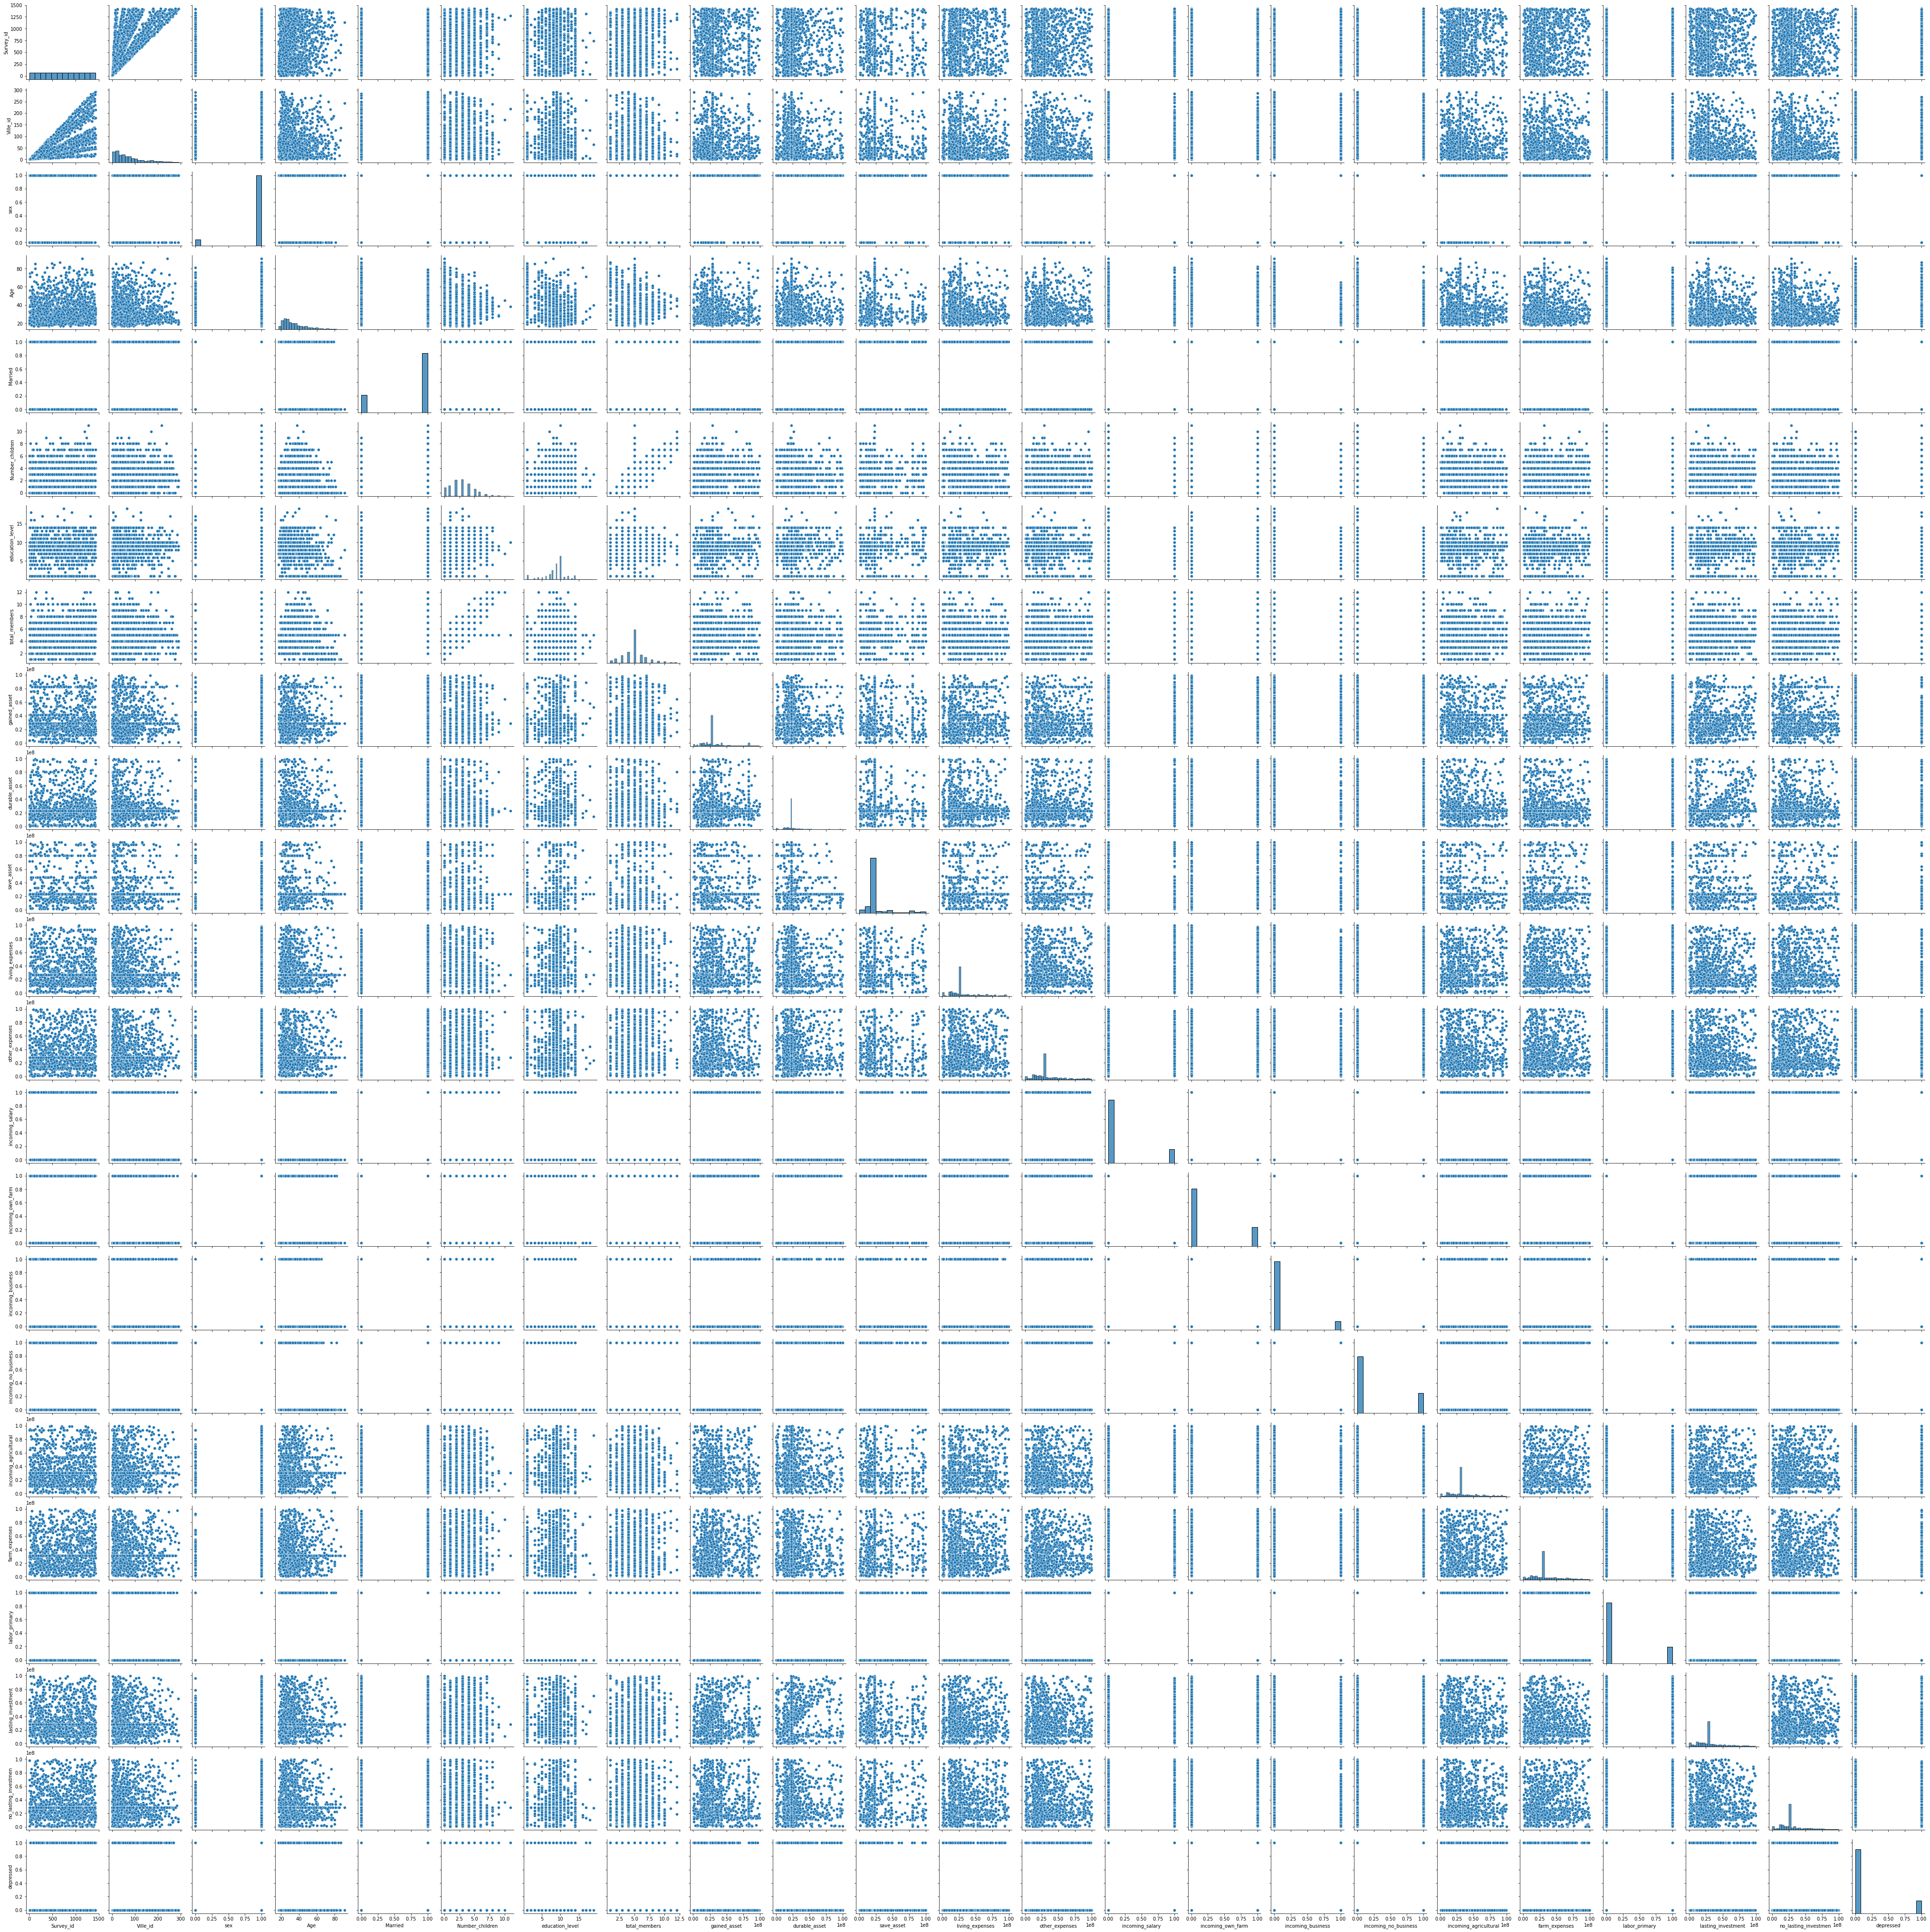

In [26]:
sns.pairplot(data)

In [27]:
data.head()

,Survey_id,Ville_id,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,...,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
0,926,91,1,28,1,4,10,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1,747,57,1,23,1,3,8,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,1
2,1190,115,1,22,1,3,9,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
3,1065,97,1,27,1,2,10,4,52667108,19698904,...,0,1,0,1,22288055,18751329,0,7781123,69219765.0,0
4,806,42,0,59,0,4,10,6,82606287,17352654,...,1,0,0,0,53384566,20731006,1,20100562,43419447.0,0


C:\Users\91808\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='depressed', ylabel='count'>

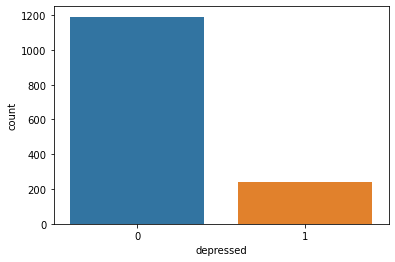

In [28]:
sns.countplot(data['depressed'])

### Data engineering

In [29]:
data['depressed'].value_counts()

0    1191
1     238
Name: depressed, dtype: int64

In [30]:
d_depressed0 = data[data['depressed']==0]
d_depressed1 = data[data['depressed']==1]


In [31]:
d_depressed0_re = resample((d_depressed0), replace=True,  n_samples= 1191, random_state=42)
d_depressed1_re = resample(d_depressed1, replace=True,  n_samples= 1191, random_state=42)

In [32]:
data1 = pd.concat([d_depressed0_re,d_depressed1_re])

In [33]:
data1['depressed'].value_counts()

0    1191
1    1191
Name: depressed, dtype: int64

### Model creation and validation

In [34]:
x = data.drop(columns = ['Survey_id','Ville_id','depressed'],axis = 1)
y = data['depressed']

In [35]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state = 42,test_size = 0.20)

In [36]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

### Logistic Regression

In [37]:
model_lr = LogisticRegression()
model_lr.fit(xtrain,ytrain)

LogisticRegression()

In [38]:
lr_predicted = model_lr.predict(xtest)

In [39]:
cm_lr = confusion_matrix(ytest,lr_predicted)

In [40]:
cm_lr

array([[239,   0],
       [ 47,   0]], dtype=int64)

<AxesSubplot:>

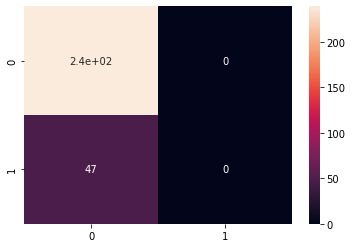

In [41]:
sns.heatmap(cm_lr,annot = True)

In [42]:
model_lr.score(xtest,ytest)

0.8356643356643356

In [43]:
cr_lr = classification_report(ytest,lr_predicted)
print(cr_lr)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       239
           1       0.00      0.00      0.00        47

    accuracy                           0.84       286
   macro avg       0.42      0.50      0.46       286
weighted avg       0.70      0.84      0.76       286



C:\Users\91808\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91808\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91808\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### SVM

In [44]:
model_svm = SVC()
model_svm.fit(xtrain,ytrain)

SVC()

In [45]:
svm_predicted = model_svm.predict(xtest)

In [46]:
model_svm.score(xtest,ytest)

0.8356643356643356

In [47]:
cm_svm = confusion_matrix(ytest,svm_predicted)
cm_svm

array([[239,   0],
       [ 47,   0]], dtype=int64)

<AxesSubplot:>

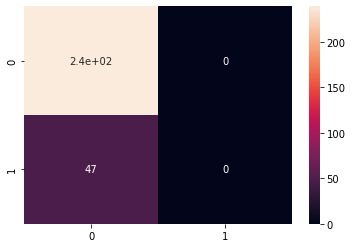

In [48]:
sns.heatmap(cm_svm,annot = True)

In [49]:
cr_svm = classification_report(ytest,svm_predicted)

C:\Users\91808\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91808\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91808\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [50]:
print(cr_svm)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       239
           1       0.00      0.00      0.00        47

    accuracy                           0.84       286
   macro avg       0.42      0.50      0.46       286
weighted avg       0.70      0.84      0.76       286



### Decision tree

In [51]:
model_dt = DecisionTreeClassifier()
model_dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [52]:
dt_predicted = model_dt.predict(xtest)

In [53]:
model_dt.score(xtest,ytest)

0.7342657342657343

In [54]:
cm_dt = confusion_matrix(ytest,dt_predicted)
cm_dt

array([[201,  38],
       [ 38,   9]], dtype=int64)

<AxesSubplot:>

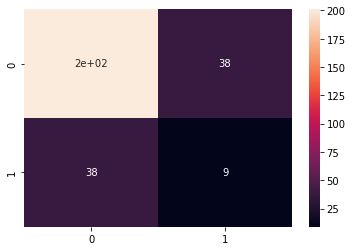

In [55]:
sns.heatmap(cm_dt,annot = True)

In [56]:
cr_dt = classification_report(ytest,dt_predicted)

In [57]:
print(cr_dt)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       239
           1       0.19      0.19      0.19        47

    accuracy                           0.73       286
   macro avg       0.52      0.52      0.52       286
weighted avg       0.73      0.73      0.73       286



### Random forest

In [58]:
model_rf = RandomForestClassifier()
model_rf.fit(xtrain,ytrain)

RandomForestClassifier()

In [59]:
rf_predicted = model_rf.predict(xtest)

In [60]:
model_rf.score(xtest,ytest)

0.8321678321678322

In [61]:
cm_rf = confusion_matrix(ytest,rf_predicted)
cm_rf

array([[235,   4],
       [ 44,   3]], dtype=int64)

<AxesSubplot:>

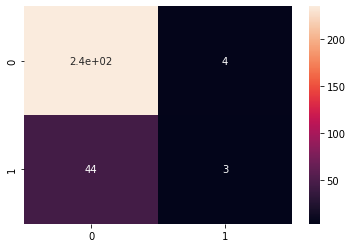

In [62]:
sns.heatmap(cm_rf,annot = True)

In [63]:
cr_rf = classification_report(ytest,rf_predicted)

In [64]:
print(cr_rf)

              precision    recall  f1-score   support

           0       0.84      0.98      0.91       239
           1       0.43      0.06      0.11        47

    accuracy                           0.83       286
   macro avg       0.64      0.52      0.51       286
weighted avg       0.77      0.83      0.78       286



### K Nearest Neighbor

In [65]:
model_knn = KNeighborsClassifier()
model_knn.fit(xtrain,ytrain)

KNeighborsClassifier()

In [66]:
knn_predicted = model_knn.predict(xtest)

In [67]:
model_knn.score(xtest,ytest)

0.7902097902097902

In [68]:
cm_knn = confusion_matrix(ytest,knn_predicted)
cm_knn

array([[224,  15],
       [ 45,   2]], dtype=int64)

<AxesSubplot:>

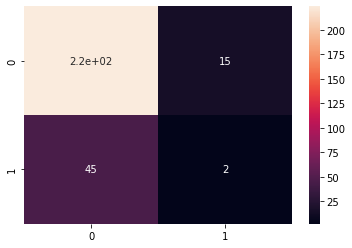

In [69]:
sns.heatmap(cm_knn,annot = True)

In [70]:
cr_knn = classification_report(ytest,knn_predicted)

In [71]:
print(cr_knn)

              precision    recall  f1-score   support

           0       0.83      0.94      0.88       239
           1       0.12      0.04      0.06        47

    accuracy                           0.79       286
   macro avg       0.48      0.49      0.47       286
weighted avg       0.72      0.79      0.75       286

